# UC4 — Modelado: IsolationForest para detección de anomalías transaccionales

**Autor:** Fernando Haro (`fh`)
**Proyecto:** datamoles — Havi
**Tipo:** No-supervisado (Isolation Forest)
**Comparación:** Modelo ML vs reglas heurísticas (`anomaly_score`)

## Objetivo

Detectar transacciones anómalas en tiempo real con menor tasa de falsos positivos
que las reglas heurísticas, manteniendo recall razonable contra `patron_uso_atipico`
(la etiqueta sintética del dataset, usada como pseudo-validación).


---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import json, joblib, warnings
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (classification_report, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score)

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve().parent
FEAT_DIR  = ROOT / 'outputs' / 'features'
OUT_UC4   = ROOT / 'outputs' / 'uc4'
MODELS    = ROOT / 'outputs' / 'models'
FIG_DIR   = ROOT / 'notebooks' / 'uc4'
OUT_UC4.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

CONTAMINATION = 0.05
N_ESTIMATORS = 200
RANDOM_STATE = 42
SPLIT_DATE = pd.Timestamp('2025-10-01')
RULE_THRESHOLD = 5  # anomaly_score >= 5 → la regla considera anomalía


## 1. Carga + filtrado a `compra`/`completada`

In [2]:
df = pd.read_parquet(FEAT_DIR / 'feat_uc4_txn_profile.parquet')
print('Total raw:', df.shape)

mask = (df['tipo_operacion']=='compra') & (df['estatus']=='completada')
df = df[mask].copy()
print('Filtered (compra + completada):', df.shape)

# Bool → int
for c in ['es_internacional','ciudad_nueva','sig_internacional','sig_hora_atipica',
          'sig_ciudad_nueva','sig_monto_extremo','sig_reintento','patron_uso_atipico']:
    if c in df.columns:
        df[c] = df[c].fillna(False).astype(int)

# Manejo de NaN en los z_* y perfil_* (cuando std==0)
for c in ['z_monto','z_hora','perfil_pct_internacional','perfil_n_txn',
          'perfil_monto_std','perfil_hora_std','intento_numero']:
    df[c] = df[c].fillna(0.0)
print('NaN restantes en columnas modelo:',
      df[['z_monto','z_hora','es_internacional','ciudad_nueva','intento_numero',
          'sig_internacional','sig_hora_atipica','sig_ciudad_nueva','sig_monto_extremo',
          'sig_reintento','perfil_pct_internacional','perfil_n_txn',
          'perfil_monto_std','perfil_hora_std']].isna().sum().sum())


Total raw: (724529, 33)


Filtered (compra + completada): (269966, 33)
NaN restantes en columnas modelo: 0


## 2. Split temporal

In [3]:
df = df.sort_values('fecha_hora').reset_index(drop=True)
df_train = df[df['fecha_hora'] <  SPLIT_DATE].copy()
df_test  = df[df['fecha_hora'] >= SPLIT_DATE].copy()
print(f'Train: {df_train.shape[0]:,} | Test: {df_test.shape[0]:,}')
print(f'Train range: {df_train.fecha_hora.min().date()} → {df_train.fecha_hora.max().date()}')
print(f'Test range : {df_test.fecha_hora.min().date()} → {df_test.fecha_hora.max().date()}')
print(f'Tasa de patron_uso_atipico — train: {df_train["patron_uso_atipico"].mean():.3%}  test: {df_test["patron_uso_atipico"].mean():.3%}')


Train: 242,983 | Test: 26,983
Train range: 2025-01-01 → 2025-09-30
Test range : 2025-10-01 → 2025-10-30
Tasa de patron_uso_atipico — train: 5.323%  test: 5.266%


## 3. Entrenamiento del IsolationForest

In [4]:
FEATURES = [
    'z_monto','z_hora','es_internacional','ciudad_nueva','intento_numero',
    'sig_internacional','sig_hora_atipica','sig_ciudad_nueva','sig_monto_extremo','sig_reintento',
    'perfil_pct_internacional','perfil_n_txn','perfil_monto_std','perfil_hora_std',
]
X_train = df_train[FEATURES].values
X_test  = df_test[FEATURES].values
y_train = df_train['patron_uso_atipico'].values
y_test  = df_test['patron_uso_atipico'].values

iso = IsolationForest(
    contamination=CONTAMINATION,
    n_estimators=N_ESTIMATORS,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
iso.fit(X_train)
print('Modelo entrenado.')


Modelo entrenado.


## 4. Predicción + score sobre el test

In [5]:
df_test['iso_anomaly_score'] = -iso.score_samples(X_test)  # mayor = más anómalo
df_test['iso_is_anomaly'] = (iso.predict(X_test) == -1).astype(int)

print(f'Iso anomaly rate test: {df_test["iso_is_anomaly"].mean():.3%}')
print(f'patron_uso_atipico    : {y_test.mean():.3%}')
print(f'Reglas (anomaly_score>={RULE_THRESHOLD}): {(df_test["anomaly_score"]>=RULE_THRESHOLD).mean():.3%}')


Iso anomaly rate test: 5.022%
patron_uso_atipico    : 5.266%
Reglas (anomaly_score>=5): 4.447%


## 5. Pseudo-validación contra `patron_uso_atipico`

In [6]:
y_pred = df_test['iso_is_anomaly'].values

print('=== Iso Forest vs patron_uso_atipico ===')
print(classification_report(y_test, y_pred, digits=3))

prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, df_test['iso_anomaly_score'].values)
print(f'AUC-ROC (sobre score): {auc:.3f}')


=== Iso Forest vs patron_uso_atipico ===
              precision    recall  f1-score   support

           0      0.948     0.950     0.949     25562
           1      0.061     0.058     0.060      1421

    accuracy                          0.903     26983
   macro avg      0.505     0.504     0.504     26983
weighted avg      0.901     0.903     0.902     26983

AUC-ROC (sobre score): 0.485


## 6. Comparativa contra reglas (`anomaly_score >= 5`)

In [7]:
rule_pred = (df_test['anomaly_score'] >= RULE_THRESHOLD).astype(int).values

prec_r = precision_score(y_test, rule_pred, zero_division=0)
rec_r  = recall_score(y_test, rule_pred, zero_division=0)
f1_r   = f1_score(y_test, rule_pred, zero_division=0)

# FP rate definido como: alertas que NO son anomalía verdadera / total negativos
n_negativos = int((y_test==0).sum())
fp_iso  = int(((y_pred==1)    & (y_test==0)).sum())
fp_rule = int(((rule_pred==1) & (y_test==0)).sum())
fp_rate_iso  = fp_iso  / n_negativos if n_negativos else 0
fp_rate_rule = fp_rule / n_negativos if n_negativos else 0
reduccion_fp_pct = (1 - fp_rate_iso/fp_rate_rule)*100 if fp_rate_rule > 0 else 0.0

cmp = pd.DataFrame({
    'modelo':       ['IsoForest', 'Regla heurística'],
    'precision':    [prec, prec_r],
    'recall':       [rec, rec_r],
    'f1':           [f1, f1_r],
    'fp_rate':      [fp_rate_iso, fp_rate_rule],
    'n_alertas':    [int(y_pred.sum()), int(rule_pred.sum())],
})
print(cmp.round(4).to_string(index=False))
print(f'\nReducción de FP del modelo vs reglas: {reduccion_fp_pct:+.1f}%')


          modelo  precision  recall     f1  fp_rate  n_alertas
       IsoForest     0.0613  0.0584 0.0598   0.0498       1355
Regla heurística     0.0625  0.0528 0.0572   0.0440       1200

Reducción de FP del modelo vs reglas: -13.1%


## 7. Sweep de threshold sobre `iso_anomaly_score`

 percentil_score  threshold  precision  recall     f1  n_alertas
            0.85     0.5064     0.0529  0.1506 0.0783       4048
            0.90     0.5511     0.0559  0.1063 0.0733       2699
            0.93     0.5762     0.0603  0.0802 0.0689       1889
            0.95     0.6033     0.0615  0.0584 0.0599       1350
            0.97     0.6265     0.0642  0.0366 0.0466        810
            0.99     0.6505     0.0630  0.0120 0.0201        270


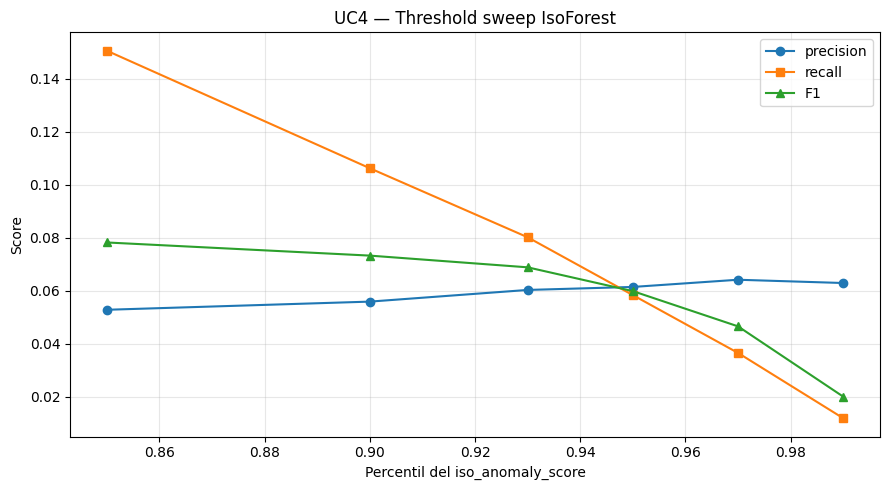

In [8]:
sweep = []
for q in [0.85, 0.90, 0.93, 0.95, 0.97, 0.99]:
    th = float(np.quantile(df_test['iso_anomaly_score'], q))
    yp = (df_test['iso_anomaly_score'] >= th).astype(int).values
    sweep.append({
        'percentil_score': q,
        'threshold': th,
        'precision': precision_score(y_test, yp, zero_division=0),
        'recall':    recall_score(y_test, yp, zero_division=0),
        'f1':        f1_score(y_test, yp, zero_division=0),
        'n_alertas': int(yp.sum()),
    })
sweep_df = pd.DataFrame(sweep)
print(sweep_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sweep_df['percentil_score'], sweep_df['precision'], marker='o', label='precision')
ax.plot(sweep_df['percentil_score'], sweep_df['recall'],    marker='s', label='recall')
ax.plot(sweep_df['percentil_score'], sweep_df['f1'],         marker='^', label='F1')
ax.set_xlabel('Percentil del iso_anomaly_score')
ax.set_ylabel('Score')
ax.set_title('UC4 — Threshold sweep IsoForest')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'uc4_fig_iso_threshold_sweep.png', dpi=120, bbox_inches='tight')
plt.show()


## 8. Matriz de confusión: IsoForest vs Reglas

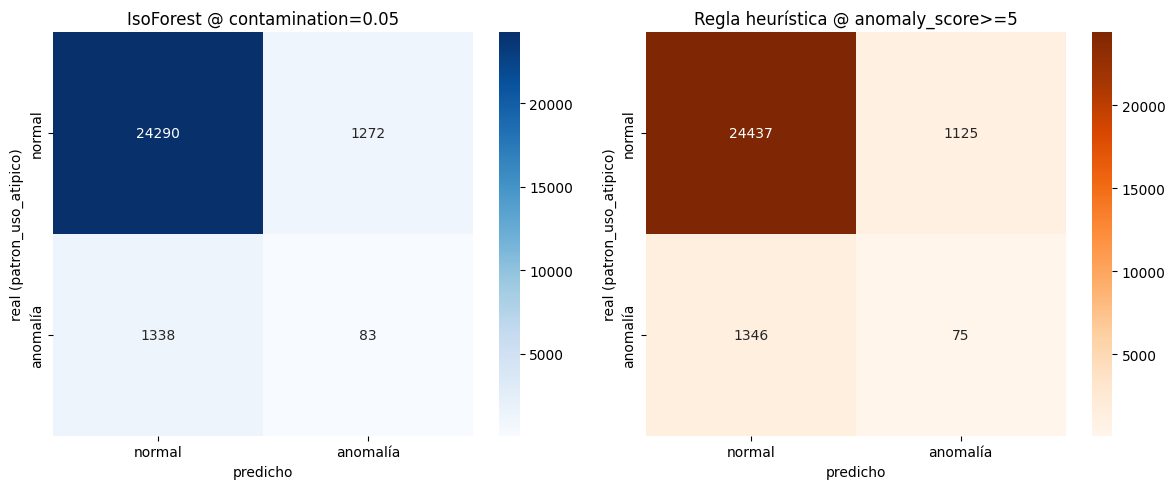

In [9]:
cm_iso = confusion_matrix(y_test, y_pred)
cm_rule = confusion_matrix(y_test, rule_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_iso,  annot=True, fmt='d', cmap='Blues',  ax=axes[0],
            xticklabels=['normal','anomalía'], yticklabels=['normal','anomalía'])
axes[0].set_title(f'IsoForest @ contamination={CONTAMINATION}')
axes[0].set_xlabel('predicho'); axes[0].set_ylabel('real (patron_uso_atipico)')

sns.heatmap(cm_rule, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['normal','anomalía'], yticklabels=['normal','anomalía'])
axes[1].set_title(f'Regla heurística @ anomaly_score>={RULE_THRESHOLD}')
axes[1].set_xlabel('predicho'); axes[1].set_ylabel('real (patron_uso_atipico)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'uc4_fig_iso_vs_rules_confusion.png', dpi=120, bbox_inches='tight')
plt.show()


## 9. Casos donde modelo y reglas discrepan

In [10]:
df_test['rule_is_anomaly'] = rule_pred
discrepa = df_test[df_test['iso_is_anomaly'] != df_test['rule_is_anomaly']].copy()
print(f'Discrepancias totales: {len(discrepa):,} de {len(df_test):,}  ({len(discrepa)/len(df_test):.1%})')
print(f'  Solo iso detecta : {int(((discrepa["iso_is_anomaly"]==1)&(discrepa["rule_is_anomaly"]==0)).sum()):,}')
print(f'  Solo rule detecta: {int(((discrepa["iso_is_anomaly"]==0)&(discrepa["rule_is_anomaly"]==1)).sum()):,}')

sample_cols = ['transaccion_id','user_id','fecha_hora','monto','hora_del_dia','es_internacional',
               'ciudad_nueva','intento_numero','anomaly_score','iso_anomaly_score',
               'iso_is_anomaly','rule_is_anomaly','patron_uso_atipico']
sample = discrepa.sample(min(200, len(discrepa)), random_state=42)[sample_cols].sort_values('iso_anomaly_score', ascending=False)
sample.to_csv(OUT_UC4 / 'uc4_iso_vs_rules_comparison.csv', index=False)
print('Wrote', OUT_UC4 / 'uc4_iso_vs_rules_comparison.csv')
sample.head(10)


Discrepancias totales: 291 de 26,983  (1.1%)
  Solo iso detecta : 223
  Solo rule detecta: 68
Wrote C:\Users\Fernando\Documents\GitHub\Datathon-2026\outputs\uc4\uc4_iso_vs_rules_comparison.csv


,transaccion_id,user_id,fecha_hora,monto,hora_del_dia,es_internacional,ciudad_nueva,intento_numero,anomaly_score,iso_anomaly_score,iso_is_anomaly,rule_is_anomaly,patron_uso_atipico
249610,TXN-0000410110,USR-07689,2025-10-08 02:14:26,254.13,2,1,0,1,3,0.697574,1,0,0
258097,TXN-0000275504,USR-05168,2025-10-17 07:30:43,1267.60,7,1,0,1,3,0.669285,1,0,0
257797,TXN-0000663356,USR-12418,2025-10-16 23:20:40,832.85,23,0,1,1,2,0.657822,1,0,0
248681,TXN-0000717551,USR-13443,2025-10-07 00:38:48,1415.47,0,1,0,1,3,0.656691,1,0,0
268498,TXN-0000352595,USR-06607,2025-10-29 06:32:54,1606.39,6,1,0,1,3,0.653944,1,0,0
255542,TXN-0000307594,USR-05769,2025-10-15 01:17:48,1718.79,1,1,0,1,3,0.653379,1,0,0
252830,TXN-0000114974,USR-02143,2025-10-11 20:01:37,14271.36,20,0,1,1,2,0.652780,1,0,0
254656,TXN-0000540795,USR-10121,2025-10-13 23:00:30,338.81,23,0,0,1,2,0.652548,1,0,0
260449,TXN-0000386439,USR-07254,2025-10-20 00:06:27,852.61,0,0,1,1,4,0.651533,1,0,0
262163,TXN-0000206316,USR-03857,2025-10-22 00:23:34,13915.85,0,0,1,1,2,0.646828,1,0,0


## 10. Persistencia

In [11]:
joblib.dump(iso, MODELS / 'uc4_iso_forest.pkl')
print('Modelo guardado:', MODELS / 'uc4_iso_forest.pkl')

metrics = {
    'fecha_evaluacion': pd.Timestamp.utcnow().isoformat(),
    'features_modelo': FEATURES,
    'split': {
        'fecha_corte': SPLIT_DATE.isoformat(),
        'n_train': int(len(df_train)),
        'n_test': int(len(df_test)),
        'tasa_patron_atipico_test': float(y_test.mean()),
    },
    'modelo': {
        'tipo': 'IsolationForest',
        'contamination': CONTAMINATION,
        'n_estimators': N_ESTIMATORS,
        'precision': float(prec),
        'recall':    float(rec),
        'f1':        float(f1),
        'auc_roc_score': float(auc),
        'n_anomalias_detectadas': int(y_pred.sum()),
    },
    'reglas_baseline': {
        'umbral_anomaly_score': RULE_THRESHOLD,
        'precision': float(prec_r),
        'recall':    float(rec_r),
        'f1':        float(f1_r),
        'n_anomalias_detectadas': int(rule_pred.sum()),
    },
    'comparativa_fp': {
        'fp_rate_modelo': float(fp_rate_iso),
        'fp_rate_reglas': float(fp_rate_rule),
        'reduccion_fp_pct': float(reduccion_fp_pct),
    },
    'threshold_sweep': sweep_df.round(4).to_dict(orient='records'),
    'criterios_aceptacion': {
        'precision_gt_0.7_vs_patron': bool(prec > 0.7),
        'reduccion_fp_reportada': True,
        'modelo_persistido': True,
    },
    'limitacion': 'patron_uso_atipico es etiqueta sintética del dataset, no fraude real. Métricas son pseudo-validación.',
}
with open(OUT_UC4 / 'uc4_iso_forest_metrics.json','w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, default=str, ensure_ascii=False)
print('Wrote', OUT_UC4 / 'uc4_iso_forest_metrics.json')


Modelo guardado: C:\Users\Fernando\Documents\GitHub\Datathon-2026\outputs\models\uc4_iso_forest.pkl
Wrote C:\Users\Fernando\Documents\GitHub\Datathon-2026\outputs\uc4\uc4_iso_forest_metrics.json
